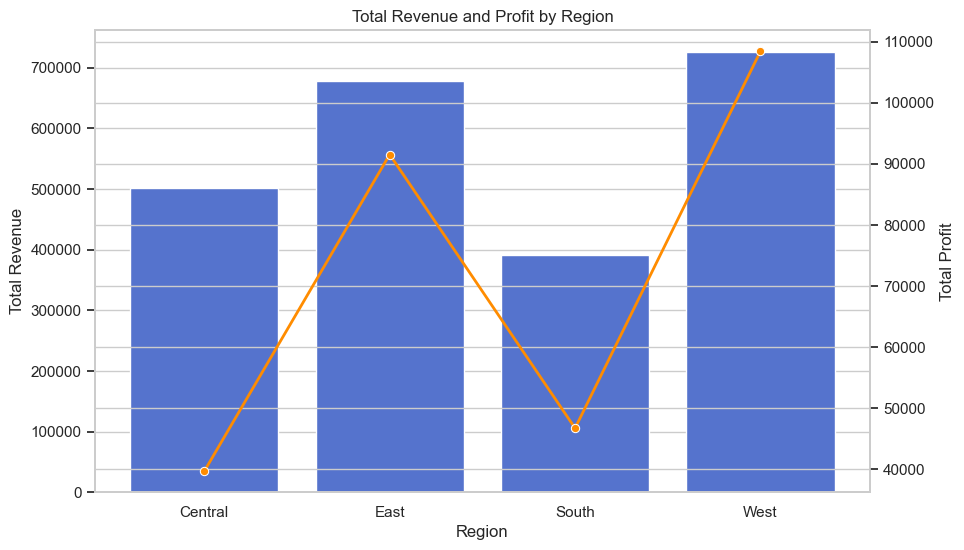

C:\Users\arpit\AppData\Local\Temp\ipykernel_16428\3534692118.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_monthly, x='Region', y='Margin_Pct', palette='Set2')


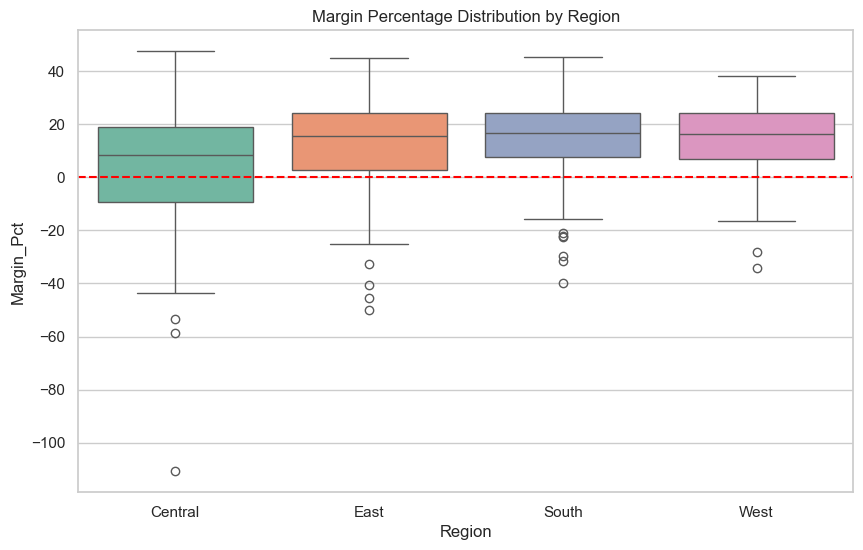

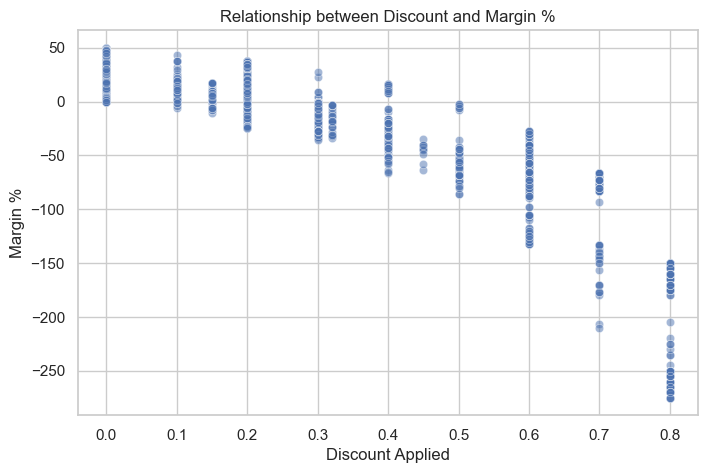

In [2]:
"""
=============================================================================
Project: Business Performance & Financial Operations Analytics
File Name: 02_eda_orientation.ipynb
Directory: notebooks/
Description: Generates orientation visuals (Revenue/Profit trends, Margin 
             distribution, and Discount vs. Margin correlation) to guide 
             the upcoming SQL root-cause analysis.
=============================================================================
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# Using raw strings to avoid that syntax warning!
df_monthly = pd.read_csv(r"D:\Financial_Ops_Analytics_Project\data\processed\monthly_unit_performance.csv")
df_raw = pd.read_csv(r"D:\Financial_Ops_Analytics_Project\data\processed\cleaned_transactions.csv") # Assuming this is where you saved the row-level data

sns.set_theme(style="whitegrid")

# 2. Visual 1: Revenue and Profit by Region (Spot the underperformer)
region_summary = df_monthly.groupby('Region')[['Revenue', 'Profit']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=region_summary, x='Region', y='Revenue', color='royalblue', ax=ax1)
ax1.set_ylabel('Total Revenue')
ax1.set_title('Total Revenue and Profit by Region')

ax2 = ax1.twinx()
sns.lineplot(data=region_summary, x='Region', y='Profit', color='darkorange', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Total Profit')
plt.show()

# 3. Visual 2: Margin % Distribution (Where is margin structurally thin?)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_monthly, x='Region', y='Margin_Pct', palette='Set2')
plt.title('Margin Percentage Distribution by Region')
plt.axhline(0, color='red', linestyle='--') 
plt.show()

# 4. Visual 3: Discount vs. Margin (Early signal for root cause)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_raw, x='Discount', y='Margin_Pct', alpha=0.5)
plt.title('Relationship between Discount and Margin %')
plt.xlabel('Discount Applied')
plt.ylabel('Margin %')
plt.show()